# LAB4 Debug Notebook

Biomedical Image Processing - LAB4

- Project 1: Add and estimate noise
- Project 2: Morphological operations
- Project 3: Image restoration

> 运行顺序建议：每个 Project 内按单元从上到下执行；不同 Project 相互独立。

In [7]:
# === 通用依赖与工具函数（所有项目共用）===

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

# skimage 为可选依赖，若不可用则退化为纯 numpy/scipy 实现
try:
    from skimage import restoration
    from skimage.metrics import structural_similarity as sk_ssim
    SKIMAGE_OK = True
except Exception:
    SKIMAGE_OK = False

np.random.seed(42)  # 固定随机种子，保证结果可复现


def normalize01(img):
    """将图像归一化到 [0, 1] 区间，避免数值范围差异影响后续处理"""
    img = img.astype(np.float32)
    mn, mx = img.min(), img.max()
    if mx - mn < 1e-12:        # 常数图像（最大=最小），直接返回全零
        return np.zeros_like(img, dtype=np.float32)
    return (img - mn) / (mx - mn)


def show_images(images, titles, cmap='gray', figsize=(15, 4)):
    """并排显示多幅图像，便于对比"""
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(images, titles), 1):
        plt.subplot(1, n, i)
        plt.imshow(im, cmap=cmap)
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def psnr(x, y, data_range=1.0):
    """
    计算峰值信噪比（Peak Signal-to-Noise Ratio）
    PSNR = 10 * log10(data_range^2 / MSE)，值越高表示去噪/复原效果越好
    """
    x = x.astype(np.float64)
    y = y.astype(np.float64)
    mse = np.mean((x - y) ** 2)
    if mse < 1e-15:            # 两张图几乎完全一样，MSE 约等于 0
        return 99.0
    return 10 * np.log10((data_range ** 2) / mse)


def ssim_simple(x, y):
    """
    计算结构相似性（Structural Similarity Index）
    优先使用 skimage 的 SSIM；若不可用则退化为相关性近似
    """
    if SKIMAGE_OK:
        dr = float(max(x.max(), y.max()) - min(x.min(), y.min()))
        dr = dr if dr > 1e-12 else 1.0
        return float(sk_ssim(x, y, data_range=dr))

    # 退化方案：零均值归一化后计算相关系数
    x = x.astype(np.float64)
    y = y.astype(np.float64)
    x = (x - x.mean()) / (x.std() + 1e-8)
    y = (y - y.mean()) / (y.std() + 1e-8)
    return float(np.mean(x * y))


BASE_DIR = './data'
print('SKIMAGE_OK =', SKIMAGE_OK)
print('BASE_DIR =', os.path.abspath(BASE_DIR))

SKIMAGE_OK = False
BASE_DIR = d:\coding\DIP_project\LAB4\data


## Project 1 - Add and estimate noise

要求覆盖：
1. 对 lab4-1 脑 MRI 加高斯噪声（指定均值、方差）
2. 加椒盐噪声（不同参数）
3. 从图像估计噪声参数
4. 用估计参数去噪并评价

lab4-1 shape: (160, 200) dtype: uint8 range: (np.float32(0.0), np.float32(1.0))


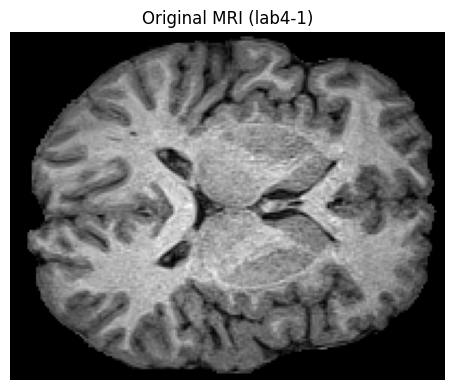

In [8]:
# === Project 1: 读取数据 ===
# 读取 .npy 格式的原始 MRI 图像（dtype 为 uint8，值域约 0-255）
img1_u8 = np.load(os.path.join(BASE_DIR, 'lab4-1.npy'))

# 归一化到 [0, 1]，使噪声参数（均值、方差）在不同图像间具有可比性
img1 = normalize01(img1_u8)

print('lab4-1 shape:', img1.shape, 'dtype:', img1_u8.dtype, 'range:', (img1.min(), img1.max()))
show_images([img1], ['Original MRI (lab4-1)'], figsize=(5, 4))

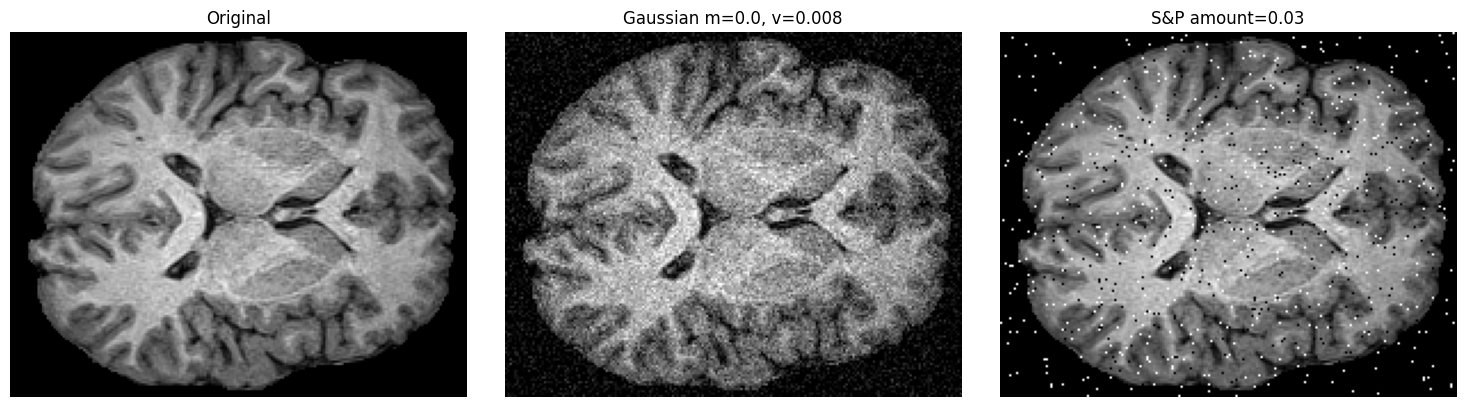

In [9]:
# === Project 1: 加噪（高斯 + 椒盐）===

def add_gaussian_noise(image01, mean=0.0, var=0.01):
    """
    在归一化图像上叠加高斯噪声
    sigma = sqrt(var)，噪声服从 N(mean, sigma^2)
    加噪后用 np.clip 限制在 [0, 1] 内
    """
    sigma = np.sqrt(var)
    noise = np.random.normal(mean, sigma, image01.shape)
    noisy = np.clip(image01 + noise, 0, 1)
    return noisy, noise


def add_salt_pepper_noise(image01, amount=0.02, salt_vs_pepper=0.5):
    """
    添加椒盐噪声
    amount: 噪声密度（占总像素的比例）
    salt_vs_pepper: 盐噪声（白点，置 1）在总噪声中的比例
    """
    noisy = image01.copy()
    n = image01.size
    n_salt = int(np.ceil(amount * n * salt_vs_pepper))      # 盐噪声像素数
    n_pepper = int(np.ceil(amount * n * (1.0 - salt_vs_pepper)))  # 胡椒噪声像素数

    # 随机选择像素坐标
    coords_s = (np.random.randint(0, image01.shape[0], n_salt),
                np.random.randint(0, image01.shape[1], n_salt))
    coords_p = (np.random.randint(0, image01.shape[0], n_pepper),
                np.random.randint(0, image01.shape[1], n_pepper))

    noisy[coords_s] = 1.0   # 盐：置为纯白
    noisy[coords_p] = 0.0   # 胡椒：置为纯黑
    return noisy


# 配置多组参数以测试不同噪声水平
gaussian_settings = [
    {'mean': 0.0, 'var': 0.002},   # 低方差高斯噪声
    {'mean': 0.0, 'var': 0.008},   # 高方差高斯噪声
    {'mean': 0.02, 'var': 0.008},  # 带亮度偏移的高斯噪声
]
sp_settings = [
    {'amount': 0.01, 'salt_vs_pepper': 0.5},   # 低密度椒盐噪声
    {'amount': 0.03, 'salt_vs_pepper': 0.5},   # 高密度椒盐噪声
    {'amount': 0.03, 'salt_vs_pepper': 0.7},   # 盐噪声偏多的椒盐噪声
]

# 使用第二组参数生成样例加噪图像
noisy_g, true_g_noise = add_gaussian_noise(img1, **gaussian_settings[1])
noisy_sp = add_salt_pepper_noise(img1, **sp_settings[1])

show_images(
    [img1, noisy_g, noisy_sp],
    ['Original',
     f"Gaussian m={gaussian_settings[1]['mean']}, v={gaussian_settings[1]['var']}",
     f"S&P amount={sp_settings[1]['amount']}"]
)

In [10]:
# === Project 1: 噪声参数估计 ===

def estimate_gaussian_noise_params(original01, noisy01, background_threshold=0.08):
    """
    在暗背景区域估计高斯噪声参数（均值、方差）
    在背景区域（原图像素值 < threshold）计算差值，避免组织结构对估计的干扰
    """
    mask_bg = original01 < background_threshold
    if mask_bg.sum() < 200:
        # 背景区域过少时退化为全图估计
        diff = noisy01 - original01
    else:
        diff = (noisy01 - original01)[mask_bg]   # 仅取背景区域的差值
    est_mean = float(np.mean(diff))
    est_var = float(np.var(diff))
    return est_mean, est_var


def estimate_salt_pepper_params(noisy01, low_th=0.05, high_th=0.95):
    """
    估计椒盐噪声参数
    盐噪声：像素值接近 1（≥ high_th）
    胡椒噪声：像素值接近 0（≤ low_th）
    """
    salt_ratio = float(np.mean(noisy01 >= high_th))     # 盐噪声占比
    pepper_ratio = float(np.mean(noisy01 <= low_th))     # 胡椒噪声占比
    amount = salt_ratio + pepper_ratio                    # 总噪声密度
    svp = salt_ratio / amount if amount > 1e-12 else 0.5  # 盐胡椒比
    return amount, svp, salt_ratio, pepper_ratio


# 对之前生成的加噪图像进行参数估计
est_mean, est_var = estimate_gaussian_noise_params(img1, noisy_g)
est_amount, est_svp, est_salt, est_pepper = estimate_salt_pepper_params(noisy_sp)

print('Gaussian true  :', gaussian_settings[1])
print('Gaussian est   :', {'mean': round(est_mean, 5), 'var': round(est_var, 5)})
print('-' * 55)
print('S&P true       :', sp_settings[1])
print('S&P est amount :', round(est_amount, 5), 'est salt_vs_pepper:', round(est_svp, 5))
print('S&P est salt/pepper ratio:', round(est_salt, 5), '/', round(est_pepper, 5))

Gaussian true  : {'mean': 0.0, 'var': 0.008}
Gaussian est   : {'mean': 0.03465, 'var': 0.0028}
-------------------------------------------------------
S&P true       : {'amount': 0.03, 'salt_vs_pepper': 0.5}
S&P est amount : 0.29241 est salt_vs_pepper: 0.05044
S&P est salt/pepper ratio: 0.01475 / 0.27766


Gaussian noisy  -> PSNR: 21.648 SSIM: 0.9509
Gaussian gaussF -> PSNR: 25.692 SSIM: 0.9831
Gaussian NLM    -> PSNR: 25.692 SSIM: 0.9831
-------------------------------------------------------
S&P noisy       -> PSNR: 20.075 SSIM: 0.9325
S&P median      -> PSNR: 28.393 SSIM: 0.9894


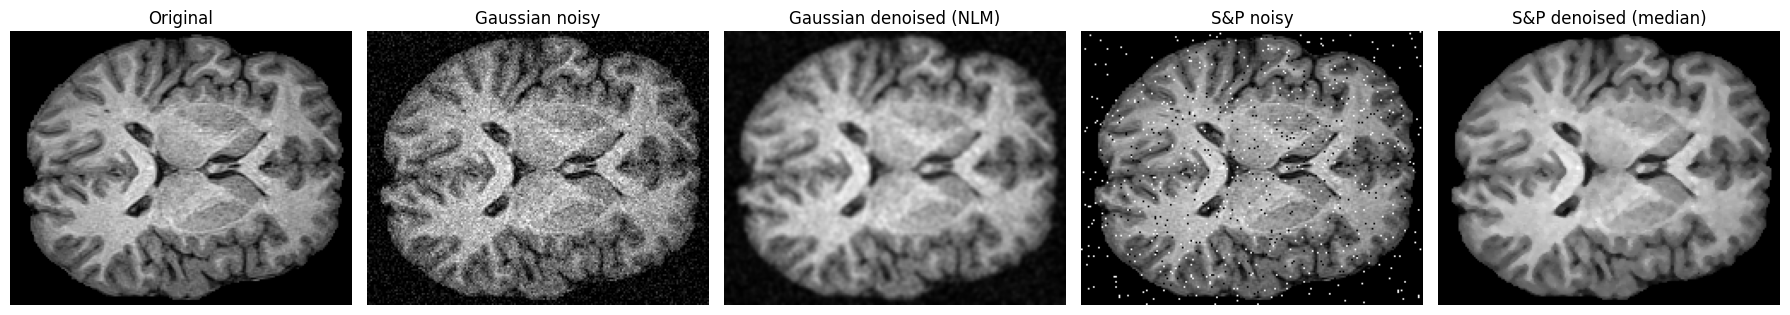

In [11]:
# === Project 1: 基于估计参数去噪并评价 ===

def denoise_gaussian(image01):
    """
    高斯噪声去噪：同时使用两种策略
    1. 高斯平滑滤波（scipy.ndimage.gaussian_filter）—— 线性方法，简单快速
    2. 非局部均值去噪（NLM）—— 利用图像自相似性，保留结构细节更好
    """
    g = ndi.gaussian_filter(image01, sigma=1.0)   # sigma 控制平滑程度
    if SKIMAGE_OK:
        h = 0.8 * np.std(image01)                   # h 为 NLM 的滤波参数
        nlm = restoration.denoise_nl_means(
            image01,
            h=h,
            patch_size=5,          # 补丁大小
            patch_distance=6,      # 搜索窗口大小
            fast_mode=True,
            channel_axis=None
        )
    else:
        nlm = g   # skimage 不可用时退化为高斯平滑
    return g, nlm


def denoise_sp(image01):
    """
    椒盐噪声去噪：中值滤波
    中值滤波用邻域像素的中位数替换中心像素，对椒盐噪声特别有效
    size=3 表示 3×3 的滤波窗口
    """
    return ndi.median_filter(image01, size=3)


# 分别对高斯噪声和椒盐噪声图像去噪
g_denoised, g_denoised_nlm = denoise_gaussian(noisy_g)
sp_denoised = denoise_sp(noisy_sp)

# 定量评价：PSNR（峰值信噪比）和 SSIM（结构相似性）
print('Gaussian noisy  -> PSNR:', round(psnr(img1, noisy_g), 3),
      'SSIM:', round(ssim_simple(img1, noisy_g), 4))
print('Gaussian gaussF -> PSNR:', round(psnr(img1, g_denoised), 3),
      'SSIM:', round(ssim_simple(img1, g_denoised), 4))
print('Gaussian NLM    -> PSNR:', round(psnr(img1, g_denoised_nlm), 3),
      'SSIM:', round(ssim_simple(img1, g_denoised_nlm), 4))
print('-' * 55)
print('S&P noisy       -> PSNR:', round(psnr(img1, noisy_sp), 3),
      'SSIM:', round(ssim_simple(img1, noisy_sp), 4))
print('S&P median      -> PSNR:', round(psnr(img1, sp_denoised), 3),
      'SSIM:', round(ssim_simple(img1, sp_denoised), 4))

# 可视化对比：原图、加噪图、去噪图
show_images(
    [img1, noisy_g, g_denoised_nlm, noisy_sp, sp_denoised],
    ['Original', 'Gaussian noisy', 'Gaussian denoised (NLM)',
     'S&P noisy', 'S&P denoised (median)'],
    figsize=(18, 4)
)

## Project 2 - Morphological operations

要求覆盖：
1. 对 `noisy_brain_mask.npy` 去噪与边界修正
2. 填补部分内部空洞（避免过度填平真实脑室）
3. 与 `brain_tissue_mask_slice.npy` 比较并检查缺陷
4. 可视化最终脑实质区域并与原图对比

noisy_mask: (528, 768) bool
gt_mask   : (528, 768) bool


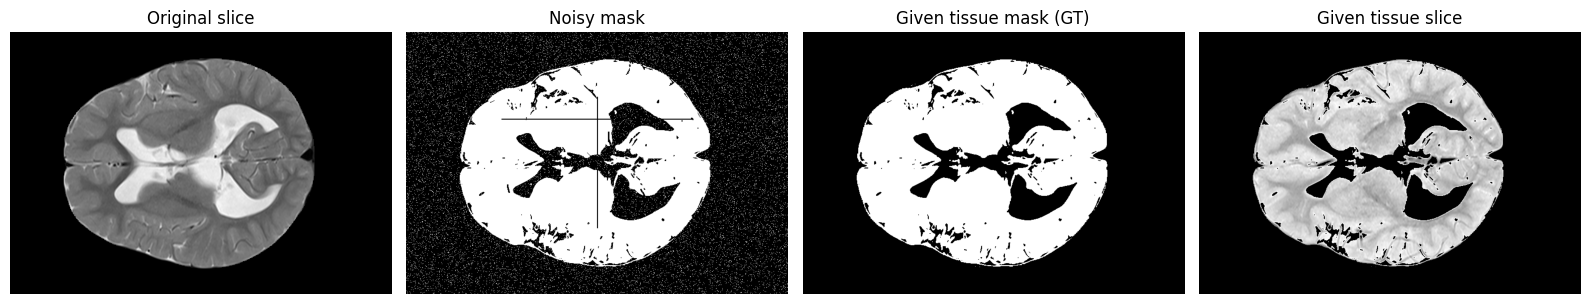

In [12]:
# === Project 2: 读取脑掩膜数据 ===

# 带噪声的脑掩膜（待处理的目标）
noisy_mask = np.load(os.path.join(BASE_DIR, 'lab4-2', 'noisy_brain_mask.npy')).astype(bool)
# 给定的脑组织掩膜（作为 Ground Truth 参考）
gt_mask = np.load(os.path.join(BASE_DIR, 'lab4-2', 'brain_tissue_mask_slice.npy')) > 0.5
# 原始脑切片和组织切片（用于可视化背景）
orig_slice = np.load(os.path.join(BASE_DIR, 'lab4-2', 'original_brain_slice_.npy')).astype(np.float32)
tissue_slice = np.load(os.path.join(BASE_DIR, 'lab4-2', 'brain_tissue_slice.npy')).astype(np.float32)

# 归一化切片图像到 [0, 1] 用于显示
orig01 = normalize01(orig_slice)
tissue01 = normalize01(tissue_slice)

print('noisy_mask:', noisy_mask.shape, noisy_mask.dtype)
print('gt_mask   :', gt_mask.shape, gt_mask.dtype)

# 可视化四份数据：原图、噪声掩膜、GT掩膜、组织切片
show_images(
    [orig01, noisy_mask.astype(float), gt_mask.astype(float), tissue01],
    ['Original slice', 'Noisy mask', 'Given tissue mask (GT)', 'Given tissue slice'],
    figsize=(16, 4)
)

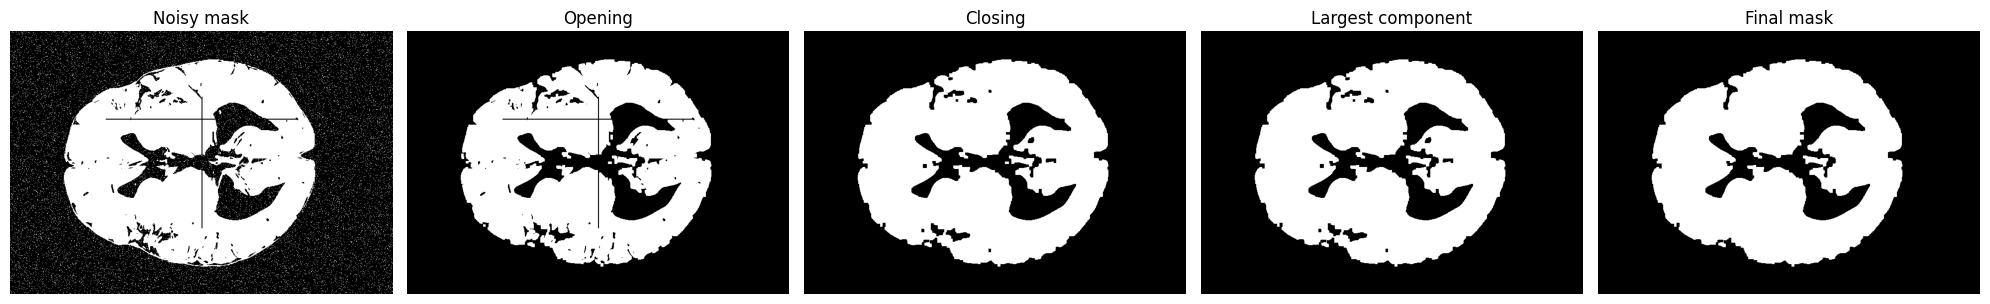

In [13]:
# === Project 2: 形态学流水线（开 -> 闭 -> 最大连通域 -> 受限孔洞填充）===

def keep_largest_component(mask):
    """
    保留二值图像中面积最大的连通域
    用 scipy.ndimage.label 标记连通分量，统计各分量像素数后仅保留最大的
    """
    labeled, n = ndi.label(mask)
    if n == 0:
        return mask
    counts = np.bincount(labeled.ravel())
    counts[0] = 0                         # 背景（label=0）不计入
    largest = np.argmax(counts)            # 像素数最多的分量编号
    return labeled == largest


def fill_small_holes_only(mask, max_hole_size=800):
    """
    只填充较小的内部孔洞，保留大的空腔（如脑室）
    孔洞 = 掩膜内部的 False 区域
    touches_border 判断孔洞是否接触图像边界（边界孔洞 = 背景，不填）
    """
    hole_map = np.logical_not(mask)        # 孔洞 = 掩膜的补集
    hole_labels, n = ndi.label(hole_map)   # 标记每个孔洞

    out = mask.copy()
    for idx in range(1, n + 1):
        region = hole_labels == idx
        area = int(region.sum())
        # 接触边界的孔洞是背景，不填充
        touches_border = (
            region[0, :].any() or region[-1, :].any() or
            region[:, 0].any() or region[:, -1].any()
        )
        if (not touches_border) and area <= max_hole_size:
            out[region] = True             # 只填小孔洞
    return out


# 形态学流水线：逐步处理
selem = np.ones((5, 5), dtype=bool)        # 5x5 方形结构元素

step_open = ndi.binary_opening(noisy_mask, structure=selem)     # 1. 开运算：去外部噪声
step_close = ndi.binary_closing(step_open, structure=selem)     # 2. 闭运算：平滑边界
step_lcc = keep_largest_component(step_close)                   # 3. 保留最大连通域
final_mask = fill_small_holes_only(step_lcc, max_hole_size=700) # 4. 受限孔洞填充

# 展示流水线每步结果
show_images(
    [noisy_mask.astype(float), step_open.astype(float),
     step_close.astype(float), step_lcc.astype(float), final_mask.astype(float)],
    ['Noisy mask', 'Opening', 'Closing', 'Largest component', 'Final mask'],
    figsize=(20, 4)
)

Before morphology:
  Dice: 0.9485
  IoU: 0.9021
  Precision: 0.9092
  Recall: 0.9914
After morphology:
  Dice: 0.9780
  IoU: 0.9570
  Precision: 0.9737
  Recall: 0.9824


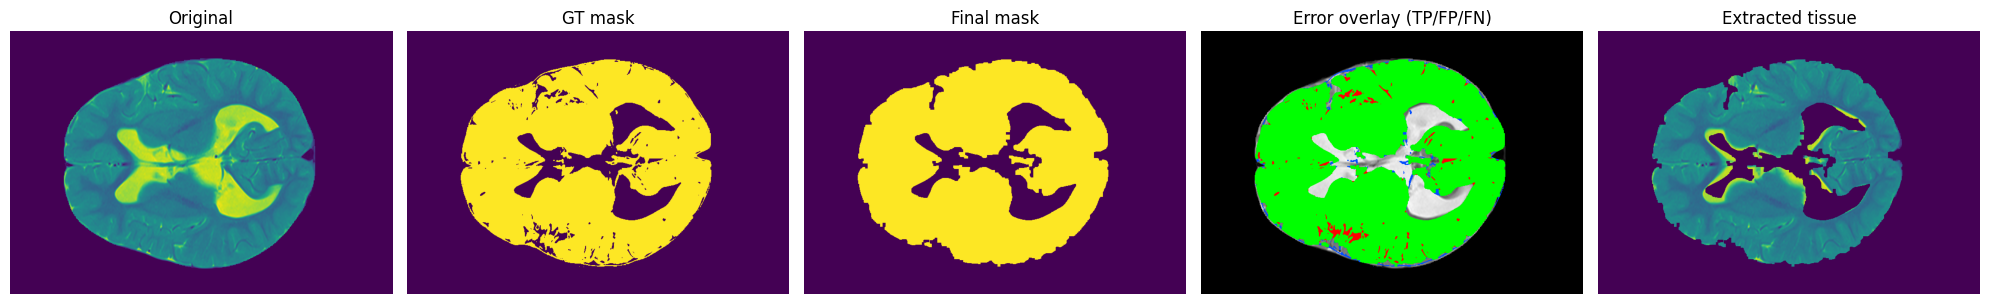


检查要点：
- 外部伪影（FP）应减少；
- 内部真实空腔（如脑室）应尽量保留；
- 脑实质边界应更连续。


In [14]:
# === Project 2: 定量评价 + 缺陷可视化 + 脑实质提取 ===

def seg_metrics(pred, gt):
    """
    计算分割评价指标
    Dice = 2*TP / (2*TP + FP + FN)    — 预测与真值的重叠度
    IoU  = TP / (TP + FP + FN)        — 交并比
    同时计算 TP/FP/FN/TN 用于误差可视化
    """
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    tp = np.logical_and(pred, gt).sum()   # 正确检测的脑组织
    tn = np.logical_and(~pred, ~gt).sum() # 正确排除的背景
    fp = np.logical_and(pred, ~gt).sum()  # 误检（噪声/伪影）
    fn = np.logical_and(~pred, gt).sum()  # 漏检（未检测到的脑组织）

    dice = 2 * tp / (2 * tp + fp + fn + 1e-12)
    iou = tp / (tp + fp + fn + 1e-12)
    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    return {'Dice': dice, 'IoU': iou, 'Precision': precision,
            'Recall': recall, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn}


# 对比处理前后的指标
m_before = seg_metrics(noisy_mask, gt_mask)
m_after = seg_metrics(final_mask, gt_mask)

print('Before morphology:')
for k in ['Dice', 'IoU', 'Precision', 'Recall']:
    print(f'  {k}: {m_before[k]:.4f}')
print('After morphology:')
for k in ['Dice', 'IoU', 'Precision', 'Recall']:
    print(f'  {k}: {m_after[k]:.4f}')

# 误差叠加图：用不同颜色标记 TP/FP/FN
# TP(绿) = 正确检测 | FP(红) = 误检 | FN(蓝) = 漏检
overlay = np.stack([orig01, orig01, orig01], axis=-1)  # 三通道 RGB 底图
tp = np.logical_and(final_mask, gt_mask)
fp = np.logical_and(final_mask, ~gt_mask)
fn = np.logical_and(~final_mask, gt_mask)
overlay[tp] = [0.0, 1.0, 0.0]    # 绿色：正确区域
overlay[fp] = [1.0, 0.0, 0.0]    # 红色：误检（外部伪影）
overlay[fn] = [0.0, 0.3, 1.0]    # 蓝色：漏检（内部缺失）

# 用最终掩膜提取脑实质（掩膜 × 原图）
extracted_tissue = orig01 * final_mask.astype(np.float32)

show_images(
    [orig01, gt_mask.astype(float), final_mask.astype(float),
     overlay, extracted_tissue],
    ['Original', 'GT mask', 'Final mask',
     'Error overlay (TP/FP/FN)', 'Extracted tissue'],
    cmap=None,
    figsize=(20, 4)
)

print('\n检查要点：')
print('- 外部伪影（FP）应减少；')
print('- 内部真实空腔（如脑室）应尽量保留；')
print('- 脑实质边界应更连续。')

## Project 3 - Restoration

要求覆盖：
1. 频域高斯模糊（不同 D0）
2. 加 Rician 噪声
3. 已知核下复原：Inverse / Limited Inverse / Wiener
4. 使用 NLM 去除 Rician 噪声并评价
5. 回答：质量评价方法、核未知时怎么办

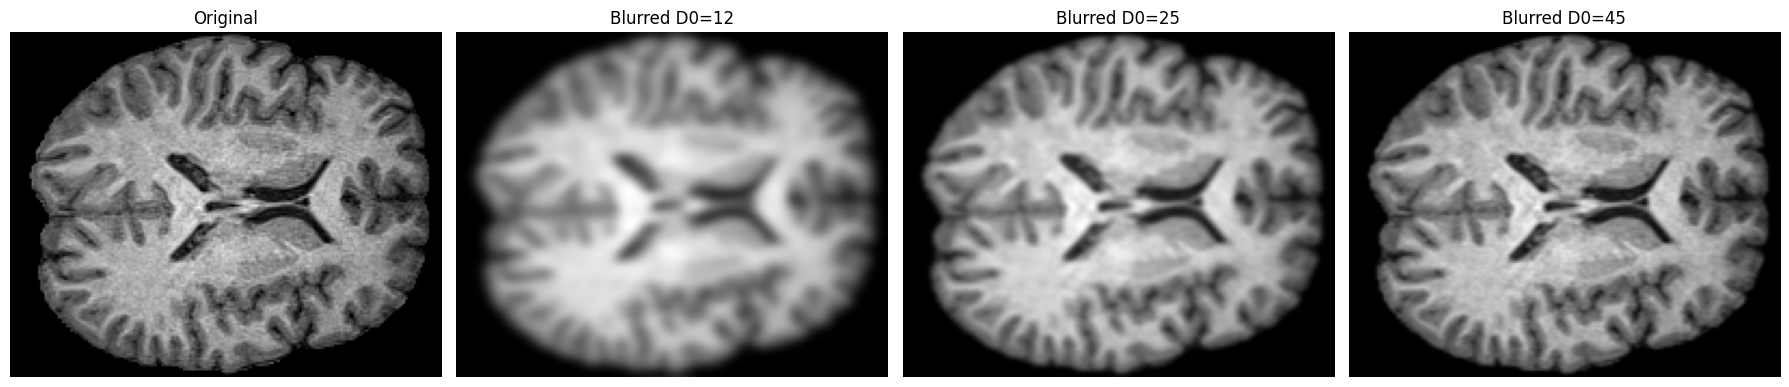

In [15]:
# === Project 3: 频域模糊 + Rician 噪声 + 复原方法 ===

# 读取 lab4-3 图像并归一化
img3_u8 = np.load(os.path.join(BASE_DIR, 'lab4-3.npy'))
img3 = normalize01(img3_u8)


def gaussian_transfer(shape, D0):
    """
    生成频域高斯低通传递函数 H(u,v)
    H(u,v) = exp(-D^2 / (2*D0^2))
    D0 为截止频率，值越小 → 高频抑制越多 → 图像越模糊
    使用 fftshift 后的坐标，低频在中心
    """
    M, N = shape
    u = np.arange(M) - M // 2       # 垂直方向频率坐标（中心化）
    v = np.arange(N) - N // 2       # 水平方向频率坐标（中心化）
    V, U = np.meshgrid(v, u)
    D2 = U**2 + V**2                 # 频率距离平方 D^2(u,v)
    H = np.exp(-D2 / (2 * (D0**2)))
    return H


def apply_freq_blur(image01, D0):
    """
    频域高斯模糊：FFT → 乘以高斯低通 H → IFFT
    返回模糊图像和传递函数 H（用于后续复原）
    """
    H = gaussian_transfer(image01.shape, D0)
    F = np.fft.fftshift(np.fft.fft2(image01))  # FFT + 中心化
    G = H * F                                    # 频域相乘（低通滤波）
    g = np.real(np.fft.ifft2(np.fft.ifftshift(G)))
    return np.clip(g, 0, 1), H


def add_rician_noise(image01, sigma=0.06):
    """
    添加 Rician 噪声（模拟 MRI 幅值图像噪声）
    noisy = sqrt((I + n1)^2 + n2^2)，n1, n2 为独立高斯噪声 N(0, sigma^2)
    """
    n1 = np.random.normal(0, sigma, image01.shape)
    n2 = np.random.normal(0, sigma, image01.shape)
    noisy = np.sqrt((image01 + n1) ** 2 + n2 ** 2)
    return np.clip(noisy, 0, 1)


def inverse_filter(noisy01, H, eps=1e-3):
    """
    直接逆滤波：F_hat = G / (H + eps)
    eps 防止除零，但对噪声非常敏感
    """
    G = np.fft.fftshift(np.fft.fft2(noisy01))
    F_hat = G / (H + eps)
    f_hat = np.real(np.fft.ifft2(np.fft.ifftshift(F_hat)))
    return np.clip(f_hat, 0, 1)


def limited_inverse_filter(noisy01, H, threshold=0.12, eps=1e-3):
    """
    受限逆滤波：仅对 |H| > threshold 的频率分量做逆滤波
    低频（H 较大处）保留，高频噪声（H 较小处）被抑制
    """
    G = np.fft.fftshift(np.fft.fft2(noisy01))
    valid = H > threshold                      # 仅保留 H 足够大的频率
    F_hat = np.zeros_like(G, dtype=np.complex128)
    F_hat[valid] = G[valid] / (H[valid] + eps)
    f_hat = np.real(np.fft.ifft2(np.fft.ifftshift(F_hat)))
    return np.clip(f_hat, 0, 1)


def wiener_filter(noisy01, H, K=0.01):
    """
    Wiener 滤波：F_hat = (H* / (|H|^2 + K)) * G
    K 为噪信比参数；K 越大 → 噪声抑制越强，但细节损失越多
    """
    G = np.fft.fftshift(np.fft.fft2(noisy01))
    Hc = np.conj(H)                            # H 的共轭
    F_hat = (Hc / (np.abs(H) ** 2 + K)) * G
    f_hat = np.real(np.fft.ifft2(np.fft.ifftshift(F_hat)))
    return np.clip(f_hat, 0, 1)


def nlm_denoise(image01):
    """
    非局部均值去噪（NLM），用于进一步去除残留噪声
    """
    if SKIMAGE_OK:
        sigma_est = np.std(image01 - ndi.gaussian_filter(image01, sigma=1.0))
        return restoration.denoise_nl_means(
            image01,
            h=1.2 * sigma_est,    # h 根据估计的噪声标准差自适应设置
            patch_size=5,
            patch_distance=6,
            fast_mode=True,
            channel_axis=None
        )
    return ndi.gaussian_filter(image01, sigma=1.0)  # 退化方案


# 用不同 D0 生成模糊图像，观察截止频率对模糊程度的影响
# D0 越小 → 高频被抑制越多 → 图像越模糊
D0_list = [12, 25, 45]
blur_list = []
for d0 in D0_list:
    b, _ = apply_freq_blur(img3, d0)
    blur_list.append(b)

show_images([img3] + blur_list,
            ['Original'] + [f'Blurred D0={d0}' for d0 in D0_list],
            figsize=(18, 4))

Blur+Rician      PSNR=21.916  SSIM=0.9568
Inverse          PSNR=4.784  SSIM=0.0128
Limited Inverse  PSNR=18.394  SSIM=0.8934
Wiener           PSNR=17.072  SSIM=0.8563
Wiener+NLM       PSNR=23.056  SSIM=0.9746


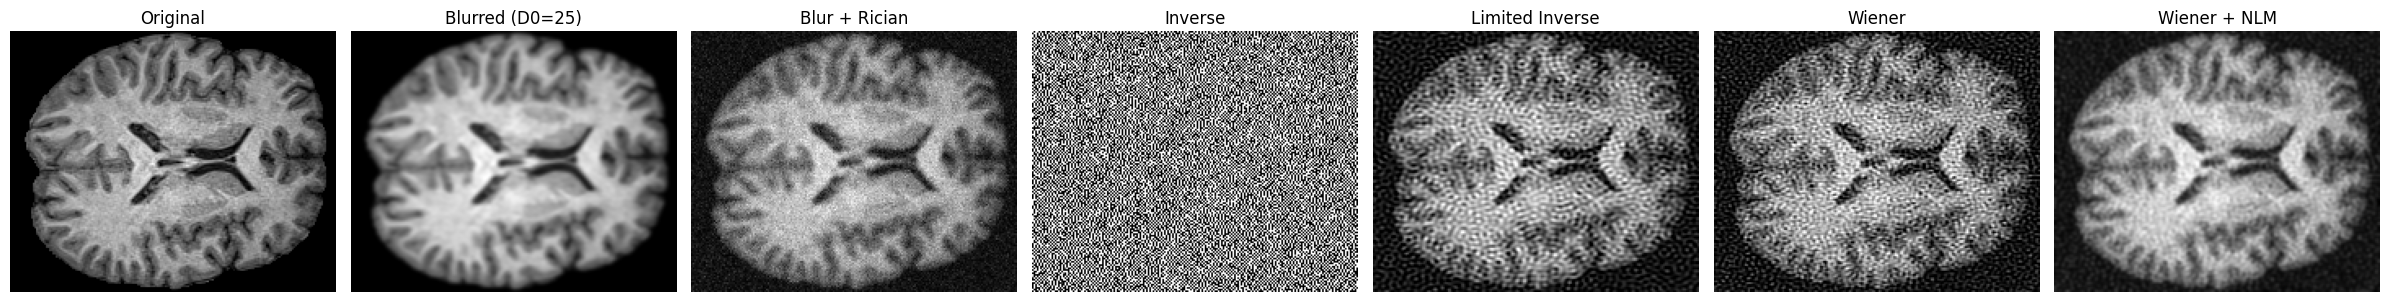


Q1 如何评价复原质量？
A1: 使用 PSNR/SSIM + 可视化对比（边界清晰度、噪声残留、伪影）。

Q2 模糊核未知怎么办？
A2: 使用盲去卷积（blind deconvolution）、先验约束或根据边缘/点扩散函数估计核。

Q3 NLM 对 Rician 噪声如何？
A3: 在保持结构细节方面通常优于线性滤波，但参数 h、搜索窗、补丁大小较敏感。


In [16]:
# === Project 3: 加 Rician 噪声 + 复原 + 评价 ===

# 选定截止频率 D0=25，进行完整的退化→复原流程
D0_use = 25
blurred, H = apply_freq_blur(img3, D0_use)       # 1. 频域高斯模糊
rician_noisy = add_rician_noise(blurred, sigma=0.06)  # 2. 叠加 Rician 噪声

# 3. 分别用三种频域复原方法
rest_inv = inverse_filter(rician_noisy, H, eps=1e-3)           # 直接逆滤波
rest_linv = limited_inverse_filter(rician_noisy, H, threshold=0.12, eps=1e-3)  # 受限逆滤波
rest_wiener = wiener_filter(rician_noisy, H, K=0.01)          # Wiener 滤波

# 4. 对 Wiener 结果进一步用 NLM 去噪
rest_wiener_nlm = nlm_denoise(rest_wiener)

# 5. 定量评价（对比原图 img3）
names = ['Blur+Rician', 'Inverse', 'Limited Inverse', 'Wiener', 'Wiener+NLM']
imgs = [rician_noisy, rest_inv, rest_linv, rest_wiener, rest_wiener_nlm]
for n, im in zip(names, imgs):
    print(f'{n:16s} PSNR={psnr(img3, im):.3f}  SSIM={ssim_simple(img3, im):.4f}')

# 可视化对比：原图 → 模糊 → 加噪 → 各方法复原
show_images(
    [img3, blurred, rician_noisy, rest_inv, rest_linv, rest_wiener, rest_wiener_nlm],
    ['Original', f'Blurred (D0={D0_use})', 'Blur + Rician',
     'Inverse', 'Limited Inverse', 'Wiener', 'Wiener + NLM'],
    figsize=(24, 4)
)

print('\nQ1 如何评价复原质量？')
print('A1: 使用 PSNR/SSIM + 可视化对比（边界清晰度、噪声残留、伪影）。')
print('\nQ2 模糊核未知怎么办？')
print('A2: 使用盲去卷积（blind deconvolution）、先验约束或根据边缘/点扩散函数估计核。')
print('\nQ3 NLM 对 Rician 噪声如何？')
print('A3: 在保持结构细节方面通常优于线性滤波，但参数 h、搜索窗、补丁大小较敏感。')

**第三步：滤波器参数调优实验**

前面的默认参数下，Inverse 因 `eps` 太小导致高频噪声放大（纯黑白噪声），Limited Inverse 的 `threshold` 和 Wiener 的 `K` 也未必是最优值。下面针对三个滤波器的关键参数进行系统测试：

- **Inverse Filter**：增大 `eps`（1e-3 → 0.02 → 0.1 → 0.3），抑制高频噪声放大
- **Limited Inverse Filter**：调节 `threshold`（0.05 / 0.12 / 0.20），控制截断频率
- **Wiener Filter**：调节 `K`（0.001 / 0.01 / 0.05 / 0.1），平衡逆滤波与噪声抑制
- **Wiener + NLM**：调优 NLM 的 `h` 参数，进一步去除残留噪声

## 环境激活命令（Windows PowerShell）

```powershell
# 若已在项目根目录 D:\coding\DIP_project
.\venv\Scripts\Activate.ps1

# 若环境目录名为 .venv
.\.venv\Scripts\Activate.ps1

# 若提示脚本执行被禁用，可先临时放开当前会话
Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass
```

退出虚拟环境：

```powershell
deactivate
```